In [1]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from monai.transforms import KeepLargestConnectedComponent
import glob

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/home/rivage/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
soop_maks_acute_folder = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_acute_registered/"
soop_masks_combined_folder = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_combined_registered/"

mask_files = sorted([f for f in os.listdir(soop_maks_acute_folder) if f.endswith('.nii') or f.endswith('.nii.gz')])

In [4]:
large_group_threshold = 15000 # minimum size of the largest connected component to be considered in large group
medium_group_threshold = 5000 # minimum size of the largest connected component to be considered in medium group
small_group_threshold = 0 # minimum size of the largest connected component to be considered in small group

large_group = []
medium_group = []
small_group = []

In [5]:
# distribute masks into groups based on the size of the largest connected component visible in the middle axial slice


# Initialize the transform
keep_largest = KeepLargestConnectedComponent()

# Count pixels in largest connected component for each mask
largest_component_sizes = []

for mask_file in tqdm(mask_files):
    # Load mask image
    #mask_img = nib.load(os.path.join(soop_maks_acute_folder, mask_file))
    mask_img = nib.load(os.path.join(soop_masks_combined_folder, mask_file))
    mask_data = mask_img.get_fdata()

    
    # Convert to binary mask
    binary_mask = mask_data > 0
    
    if np.any(binary_mask):
        # Apply MONAI's KeepLargestConnectedComponent
        largest_component = keep_largest(binary_mask.astype(np.float32))
        largest_component_size = int(np.sum(largest_component))
    else:
        largest_component_size = 0

    if largest_component_size >= large_group_threshold:
        large_group.append(mask_file)
    elif largest_component_size >= medium_group_threshold:
        medium_group.append(mask_file)
    elif largest_component_size >= small_group_threshold:
        small_group.append(mask_file)
    
    largest_component_sizes.append(largest_component_size)
    #print(f"{mask_file}: {largest_component_size} pixels in largest component")

print(f"\nSummary:")
print(f"Mean largest component size: {np.mean(largest_component_sizes):.2f}, n={len(largest_component_sizes)}")
print('\n')
print(f"Large group (>{large_group_threshold} pixels): {len(large_group)} masks")
print(f"Medium group (>{medium_group_threshold} pixels): {len(medium_group)} masks")
print(f"Small group (>{small_group_threshold} pixels): {len(small_group)} masks")

100%|██████████| 1451/1451 [29:15<00:00,  1.21s/it] 


Summary:
Mean largest component size: 7994.94, n=1451


Large group (>15000 pixels): 234 masks
Medium group (>5000 pixels): 312 masks
Small group (>0 pixels): 905 masks


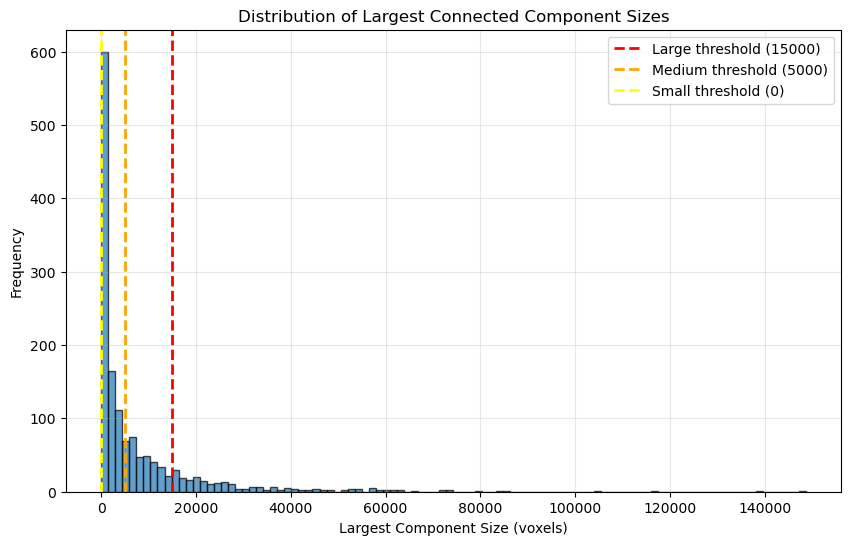

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(largest_component_sizes, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(large_group_threshold, color='red', linestyle='--', linewidth=2, label=f'Large threshold ({large_group_threshold})')
plt.axvline(medium_group_threshold, color='orange', linestyle='--', linewidth=2, label=f'Medium threshold ({medium_group_threshold})')
plt.axvline(small_group_threshold, color='yellow', linestyle='--', linewidth=2, label=f'Small threshold ({small_group_threshold})')
plt.xlabel('Largest Component Size (voxels)')
plt.ylabel('Frequency')
plt.title('Distribution of Largest Connected Component Sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_16311/1647650600.py:11: RuntimeWarning: overflow encountered in power
  return a * (x ** (-alpha))
/tmp/ipykernel_16311/1647650600.py:34: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Power law fit: α={alpha_fit:.2f}', linestyle='--')


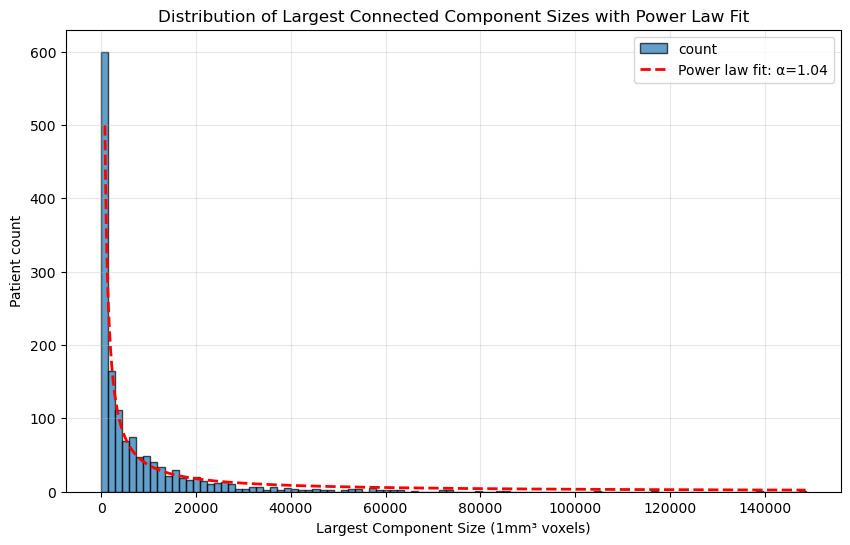

Power law parameters: a=510428.04, alpha=1.04


In [7]:
from scipy import stats
from scipy.optimize import curve_fit

# Remove zeros and small values for power law fitting
min_size_for_fit = 800

sizes_filtered = [s for s in largest_component_sizes if s >= min_size_for_fit]

# Fit power law: y = a * x^(-alpha)
def power_law(x, a, alpha):
    return a * (x ** (-alpha))

# Create histogram data
hist, bin_edges = np.histogram(sizes_filtered, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Filter out zero counts for fitting
mask = hist > 0
bin_centers_fit = bin_centers[mask]
hist_fit = hist[mask]

# Fit the power law
try:
    params, _ = curve_fit(power_law, bin_centers_fit, hist_fit, p0=[max(hist_fit), 1.5])
    a_fit, alpha_fit = params
    
    # Generate fitted curve
    x_fit = np.linspace(min_size_for_fit, max(sizes_filtered), 1000)
    y_fit = power_law(x_fit, a_fit, alpha_fit)
    
    plt.figure(figsize=(10, 6))
    plt.hist(largest_component_sizes, bins=100, edgecolor='black', alpha=0.7, label='count')

    plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Power law fit: α={alpha_fit:.2f}', linestyle='--')
    plt.xlabel('Largest Component Size (1mm³ voxels)')
    plt.ylabel('Patient count')
    plt.title('Distribution of Largest Connected Component Sizes with Power Law Fit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Power law parameters: a={a_fit:.2f}, alpha={alpha_fit:.2f}")
except:
    print("Power law fitting failed")

In [8]:
print(large_group)
print(medium_group)
print(small_group)

['sub-1.nii.gz', 'sub-1010.nii.gz', 'sub-1013.nii.gz', 'sub-1015.nii.gz', 'sub-1025.nii.gz', 'sub-1032.nii.gz', 'sub-1035.nii.gz', 'sub-1039.nii.gz', 'sub-1041.nii.gz', 'sub-1043.nii.gz', 'sub-1045.nii.gz', 'sub-1046.nii.gz', 'sub-1071.nii.gz', 'sub-1073.nii.gz', 'sub-1086.nii.gz', 'sub-1096.nii.gz', 'sub-1102.nii.gz', 'sub-1107.nii.gz', 'sub-1115.nii.gz', 'sub-113.nii.gz', 'sub-114.nii.gz', 'sub-1149.nii.gz', 'sub-1150.nii.gz', 'sub-1156.nii.gz', 'sub-116.nii.gz', 'sub-1164.nii.gz', 'sub-1165.nii.gz', 'sub-118.nii.gz', 'sub-1200.nii.gz', 'sub-1204.nii.gz', 'sub-1209.nii.gz', 'sub-1213.nii.gz', 'sub-1215.nii.gz', 'sub-1223.nii.gz', 'sub-1227.nii.gz', 'sub-1232.nii.gz', 'sub-1246.nii.gz', 'sub-1258.nii.gz', 'sub-127.nii.gz', 'sub-1280.nii.gz', 'sub-1282.nii.gz', 'sub-1283.nii.gz', 'sub-1285.nii.gz', 'sub-1292.nii.gz', 'sub-1301.nii.gz', 'sub-1305.nii.gz', 'sub-1306.nii.gz', 'sub-1309.nii.gz', 'sub-1312.nii.gz', 'sub-1314.nii.gz', 'sub-1320.nii.gz', 'sub-1323.nii.gz', 'sub-135.nii.gz', '

In [9]:
print([name.split('_')[0] for name in large_group])
print([name.split('_')[0] for name in medium_group])
print([name.split('_')[0] for name in small_group])

['sub-1.nii.gz', 'sub-1010.nii.gz', 'sub-1013.nii.gz', 'sub-1015.nii.gz', 'sub-1025.nii.gz', 'sub-1032.nii.gz', 'sub-1035.nii.gz', 'sub-1039.nii.gz', 'sub-1041.nii.gz', 'sub-1043.nii.gz', 'sub-1045.nii.gz', 'sub-1046.nii.gz', 'sub-1071.nii.gz', 'sub-1073.nii.gz', 'sub-1086.nii.gz', 'sub-1096.nii.gz', 'sub-1102.nii.gz', 'sub-1107.nii.gz', 'sub-1115.nii.gz', 'sub-113.nii.gz', 'sub-114.nii.gz', 'sub-1149.nii.gz', 'sub-1150.nii.gz', 'sub-1156.nii.gz', 'sub-116.nii.gz', 'sub-1164.nii.gz', 'sub-1165.nii.gz', 'sub-118.nii.gz', 'sub-1200.nii.gz', 'sub-1204.nii.gz', 'sub-1209.nii.gz', 'sub-1213.nii.gz', 'sub-1215.nii.gz', 'sub-1223.nii.gz', 'sub-1227.nii.gz', 'sub-1232.nii.gz', 'sub-1246.nii.gz', 'sub-1258.nii.gz', 'sub-127.nii.gz', 'sub-1280.nii.gz', 'sub-1282.nii.gz', 'sub-1283.nii.gz', 'sub-1285.nii.gz', 'sub-1292.nii.gz', 'sub-1301.nii.gz', 'sub-1305.nii.gz', 'sub-1306.nii.gz', 'sub-1309.nii.gz', 'sub-1312.nii.gz', 'sub-1314.nii.gz', 'sub-1320.nii.gz', 'sub-1323.nii.gz', 'sub-135.nii.gz', '

In [10]:
print([name.replace('.nii.gz', '') for name in large_group])
print([name.replace('.nii.gz', '') for name in medium_group])
print([name.replace('.nii.gz', '') for name in small_group])

['sub-1', 'sub-1010', 'sub-1013', 'sub-1015', 'sub-1025', 'sub-1032', 'sub-1035', 'sub-1039', 'sub-1041', 'sub-1043', 'sub-1045', 'sub-1046', 'sub-1071', 'sub-1073', 'sub-1086', 'sub-1096', 'sub-1102', 'sub-1107', 'sub-1115', 'sub-113', 'sub-114', 'sub-1149', 'sub-1150', 'sub-1156', 'sub-116', 'sub-1164', 'sub-1165', 'sub-118', 'sub-1200', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1215', 'sub-1223', 'sub-1227', 'sub-1232', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1280', 'sub-1282', 'sub-1283', 'sub-1285', 'sub-1292', 'sub-1301', 'sub-1305', 'sub-1306', 'sub-1309', 'sub-1312', 'sub-1314', 'sub-1320', 'sub-1323', 'sub-135', 'sub-1354', 'sub-1355', 'sub-1358', 'sub-1364', 'sub-1366', 'sub-1369', 'sub-1373', 'sub-1379', 'sub-1382', 'sub-1386', 'sub-1395', 'sub-1409', 'sub-1410', 'sub-1413', 'sub-1422', 'sub-1429', 'sub-1432', 'sub-1445', 'sub-1447', 'sub-1449', 'sub-1475', 'sub-1478', 'sub-148', 'sub-1480', 'sub-1483', 'sub-1485', 'sub-1488', 'sub-1507', 'sub-1508', 'sub-1511', 'sub-1517', '

In [11]:

large_group = ['sub-1', 'sub-1010', 'sub-1013', 'sub-1015', 'sub-1025', 'sub-1032', 'sub-1035', 'sub-1039', 'sub-1041', 'sub-1043', 'sub-1045', 'sub-1046', 'sub-1071', 'sub-1073', 'sub-1086', 'sub-1096', 'sub-1102', 'sub-1107', 'sub-1115', 'sub-113', 'sub-114', 'sub-1149', 'sub-1150', 'sub-1156', 'sub-116', 'sub-1164', 'sub-1165', 'sub-118', 'sub-1200', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1215', 'sub-1223', 'sub-1227', 'sub-1232', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1280', 'sub-1282', 'sub-1283', 'sub-1285', 'sub-1292', 'sub-1301', 'sub-1305', 'sub-1306', 'sub-1309', 'sub-1312', 'sub-1314', 'sub-1320', 'sub-1323', 'sub-135', 'sub-1354', 'sub-1355', 'sub-1358', 'sub-1364', 'sub-1366', 'sub-1369', 'sub-1373', 'sub-1379', 'sub-1382', 'sub-1386', 'sub-1395', 'sub-1409', 'sub-1410', 'sub-1413', 'sub-1422', 'sub-1429', 'sub-1432', 'sub-1445', 'sub-1447', 'sub-1449', 'sub-1475', 'sub-1478', 'sub-148', 'sub-1480', 'sub-1483', 'sub-1485', 'sub-1488', 'sub-1507', 'sub-1508', 'sub-1511', 'sub-1517', 'sub-1545', 'sub-1552', 'sub-1554', 'sub-1555', 'sub-1569', 'sub-1598', 'sub-1612', 'sub-1634', 'sub-1637', 'sub-1656', 'sub-1670', 'sub-1677', 'sub-1707', 'sub-1719', 'sub-1725', 'sub-1727', 'sub-173', 'sub-1736', 'sub-174', 'sub-177', 'sub-185', 'sub-190', 'sub-196', 'sub-198', 'sub-2', 'sub-221', 'sub-235', 'sub-241', 'sub-247', 'sub-249', 'sub-260', 'sub-262', 'sub-264', 'sub-278', 'sub-284', 'sub-294', 'sub-3', 'sub-303', 'sub-314', 'sub-321', 'sub-326', 'sub-331', 'sub-335', 'sub-338', 'sub-339', 'sub-341', 'sub-342', 'sub-343', 'sub-344', 'sub-345', 'sub-346', 'sub-359', 'sub-360', 'sub-366', 'sub-370', 'sub-374', 'sub-386', 'sub-398', 'sub-400', 'sub-401', 'sub-412', 'sub-42', 'sub-422', 'sub-432', 'sub-433', 'sub-443', 'sub-446', 'sub-447', 'sub-457', 'sub-463', 'sub-464', 'sub-466', 'sub-47', 'sub-477', 'sub-494', 'sub-498', 'sub-501', 'sub-505', 'sub-512', 'sub-517', 'sub-521', 'sub-523', 'sub-525', 'sub-529', 'sub-53', 'sub-530', 'sub-539', 'sub-543', 'sub-56', 'sub-563', 'sub-572', 'sub-579', 'sub-613', 'sub-620', 'sub-631', 'sub-634', 'sub-638', 'sub-651', 'sub-652', 'sub-661', 'sub-682', 'sub-692', 'sub-694', 'sub-698', 'sub-699', 'sub-707', 'sub-719', 'sub-721', 'sub-723', 'sub-724', 'sub-751', 'sub-754', 'sub-760', 'sub-761', 'sub-768', 'sub-776', 'sub-789', 'sub-79', 'sub-791', 'sub-796', 'sub-8', 'sub-803', 'sub-806', 'sub-813', 'sub-82', 'sub-823', 'sub-826', 'sub-829', 'sub-843', 'sub-844', 'sub-845', 'sub-858', 'sub-861', 'sub-865', 'sub-866', 'sub-873', 'sub-877', 'sub-881', 'sub-896', 'sub-917', 'sub-937', 'sub-939', 'sub-942', 'sub-946', 'sub-95', 'sub-952', 'sub-959', 'sub-960', 'sub-968', 'sub-990']
medium_group = ['sub-100', 'sub-1006', 'sub-1011', 'sub-1014', 'sub-1016', 'sub-1018', 'sub-102', 'sub-1024', 'sub-103', 'sub-1052', 'sub-1054', 'sub-1055', 'sub-1056', 'sub-1057', 'sub-106', 'sub-1064', 'sub-1075', 'sub-1076', 'sub-1081', 'sub-1093', 'sub-110', 'sub-1101', 'sub-1105', 'sub-1106', 'sub-1113', 'sub-1118', 'sub-1119', 'sub-112', 'sub-1120', 'sub-1127', 'sub-1128', 'sub-1130', 'sub-1133', 'sub-1136', 'sub-1140', 'sub-1144', 'sub-1147', 'sub-1148', 'sub-1154', 'sub-1157', 'sub-1163', 'sub-1182', 'sub-1183', 'sub-1186', 'sub-1189', 'sub-1193', 'sub-1198', 'sub-1202', 'sub-1211', 'sub-1212', 'sub-1217', 'sub-122', 'sub-1229', 'sub-123', 'sub-1234', 'sub-1237', 'sub-1239', 'sub-124', 'sub-1242', 'sub-1244', 'sub-1248', 'sub-1260', 'sub-1266', 'sub-1277', 'sub-128', 'sub-1281', 'sub-129', 'sub-1291', 'sub-1296', 'sub-1297', 'sub-1298', 'sub-1302', 'sub-131', 'sub-1310', 'sub-1317', 'sub-1319', 'sub-1324', 'sub-1326', 'sub-1330', 'sub-1331', 'sub-1332', 'sub-1338', 'sub-1346', 'sub-1347', 'sub-1348', 'sub-1349', 'sub-1352', 'sub-1361', 'sub-1363', 'sub-1370', 'sub-1374', 'sub-138', 'sub-1380', 'sub-1388', 'sub-1396', 'sub-1404', 'sub-1408', 'sub-1415', 'sub-1417', 'sub-1423', 'sub-1427', 'sub-1438', 'sub-1440', 'sub-1443', 'sub-1446', 'sub-145', 'sub-1450', 'sub-1458', 'sub-146', 'sub-1460', 'sub-1461', 'sub-1463', 'sub-1466', 'sub-147', 'sub-1489', 'sub-1490', 'sub-1494', 'sub-1496', 'sub-1501', 'sub-1503', 'sub-1506', 'sub-1509', 'sub-1514', 'sub-1518', 'sub-1519', 'sub-1521', 'sub-1522', 'sub-1523', 'sub-1525', 'sub-1541', 'sub-1547', 'sub-1548', 'sub-155', 'sub-1550', 'sub-1556', 'sub-1557', 'sub-156', 'sub-1562', 'sub-1565', 'sub-1567', 'sub-1568', 'sub-1571', 'sub-1578', 'sub-1583', 'sub-1595', 'sub-16', 'sub-1603', 'sub-1605', 'sub-1608', 'sub-161', 'sub-162', 'sub-1629', 'sub-1636', 'sub-1638', 'sub-1646', 'sub-165', 'sub-1652', 'sub-1660', 'sub-1672', 'sub-1673', 'sub-1674', 'sub-1678', 'sub-1682', 'sub-1683', 'sub-1684', 'sub-1688', 'sub-1690', 'sub-1695', 'sub-1697', 'sub-1701', 'sub-1715', 'sub-1722', 'sub-191', 'sub-203', 'sub-204', 'sub-206', 'sub-219', 'sub-243', 'sub-245', 'sub-25', 'sub-27', 'sub-273', 'sub-274', 'sub-277', 'sub-289', 'sub-295', 'sub-296', 'sub-297', 'sub-305', 'sub-320', 'sub-322', 'sub-328', 'sub-329', 'sub-33', 'sub-330', 'sub-332', 'sub-333', 'sub-348', 'sub-35', 'sub-352', 'sub-355', 'sub-36', 'sub-364', 'sub-375', 'sub-377', 'sub-379', 'sub-381', 'sub-382', 'sub-384', 'sub-397', 'sub-403', 'sub-408', 'sub-409', 'sub-415', 'sub-416', 'sub-420', 'sub-426', 'sub-435', 'sub-444', 'sub-449', 'sub-462', 'sub-467', 'sub-473', 'sub-478', 'sub-485', 'sub-487', 'sub-49', 'sub-490', 'sub-50', 'sub-507', 'sub-510', 'sub-515', 'sub-518', 'sub-522', 'sub-538', 'sub-541', 'sub-542', 'sub-544', 'sub-546', 'sub-551', 'sub-552', 'sub-554', 'sub-557', 'sub-560', 'sub-580', 'sub-587', 'sub-589', 'sub-594', 'sub-595', 'sub-596', 'sub-616', 'sub-62', 'sub-622', 'sub-626', 'sub-654', 'sub-657', 'sub-663', 'sub-67', 'sub-674', 'sub-68', 'sub-680', 'sub-681', 'sub-685', 'sub-69', 'sub-703', 'sub-717', 'sub-728', 'sub-75', 'sub-752', 'sub-759', 'sub-794', 'sub-795', 'sub-801', 'sub-807', 'sub-821', 'sub-822', 'sub-830', 'sub-834', 'sub-839', 'sub-848', 'sub-853', 'sub-860', 'sub-862', 'sub-869', 'sub-870', 'sub-878', 'sub-880', 'sub-888', 'sub-889', 'sub-894', 'sub-9', 'sub-908', 'sub-910', 'sub-911', 'sub-918', 'sub-924', 'sub-927', 'sub-931', 'sub-933', 'sub-943', 'sub-944', 'sub-947', 'sub-96', 'sub-965', 'sub-969', 'sub-972', 'sub-976', 'sub-982', 'sub-987', 'sub-991', 'sub-996', 'sub-998']
small_group = ['sub-10', 'sub-1000', 'sub-1001', 'sub-1003', 'sub-1004', 'sub-1005', 'sub-1007', 'sub-1009', 'sub-101', 'sub-1012', 'sub-1017', 'sub-1019', 'sub-1020', 'sub-1021', 'sub-1022', 'sub-1026', 'sub-1027', 'sub-1028', 'sub-1029', 'sub-1033', 'sub-1034', 'sub-1036', 'sub-1037', 'sub-1038', 'sub-104', 'sub-1040', 'sub-1042', 'sub-1047', 'sub-1049', 'sub-105', 'sub-1050', 'sub-1053', 'sub-1058', 'sub-1061', 'sub-1062', 'sub-1063', 'sub-1065', 'sub-1066', 'sub-1067', 'sub-1068', 'sub-1069', 'sub-1070', 'sub-1072', 'sub-1077', 'sub-1078', 'sub-108', 'sub-1082', 'sub-1083', 'sub-1084', 'sub-1085', 'sub-1087', 'sub-1088', 'sub-1089', 'sub-1090', 'sub-1091', 'sub-1092', 'sub-1095', 'sub-1098', 'sub-1099', 'sub-1100', 'sub-1104', 'sub-1108', 'sub-1109', 'sub-111', 'sub-1110', 'sub-1111', 'sub-1112', 'sub-1117', 'sub-1121', 'sub-1122', 'sub-1124', 'sub-1126', 'sub-1129', 'sub-1131', 'sub-1132', 'sub-1134', 'sub-1137', 'sub-1143', 'sub-1145', 'sub-1146', 'sub-115', 'sub-1151', 'sub-1152', 'sub-1153', 'sub-1155', 'sub-1158', 'sub-1159', 'sub-1160', 'sub-1162', 'sub-1166', 'sub-1168', 'sub-1169', 'sub-117', 'sub-1171', 'sub-1172', 'sub-1175', 'sub-1177', 'sub-1178', 'sub-1179', 'sub-1180', 'sub-1181', 'sub-1184', 'sub-1185', 'sub-1187', 'sub-1188', 'sub-119', 'sub-1190', 'sub-1191', 'sub-1192', 'sub-1195', 'sub-1197', 'sub-1199', 'sub-120', 'sub-1201', 'sub-1203', 'sub-1205', 'sub-1206', 'sub-1207', 'sub-1208', 'sub-121', 'sub-1210', 'sub-1214', 'sub-1216', 'sub-1218', 'sub-1219', 'sub-1220', 'sub-1221', 'sub-1222', 'sub-1224', 'sub-1225', 'sub-1226', 'sub-1228', 'sub-1230', 'sub-1233', 'sub-1236', 'sub-1238', 'sub-1240', 'sub-1243', 'sub-1245', 'sub-1247', 'sub-1249', 'sub-1250', 'sub-1252', 'sub-1253', 'sub-1255', 'sub-1257', 'sub-1259', 'sub-126', 'sub-1261', 'sub-1262', 'sub-1263', 'sub-1264', 'sub-1265', 'sub-1267', 'sub-1268', 'sub-1269', 'sub-1270', 'sub-1271', 'sub-1272', 'sub-1273', 'sub-1274', 'sub-1275', 'sub-1278', 'sub-1279', 'sub-1286', 'sub-1287', 'sub-1288', 'sub-1289', 'sub-1290', 'sub-1294', 'sub-1295', 'sub-1299', 'sub-13', 'sub-130', 'sub-1300', 'sub-1303', 'sub-1304', 'sub-1307', 'sub-1313', 'sub-1315', 'sub-1316', 'sub-1318', 'sub-132', 'sub-1321', 'sub-1325', 'sub-1327', 'sub-1328', 'sub-1333', 'sub-1334', 'sub-1336', 'sub-1341', 'sub-1342', 'sub-1343', 'sub-1344', 'sub-1345', 'sub-1350', 'sub-1351', 'sub-1353', 'sub-1356', 'sub-1359', 'sub-136', 'sub-1360', 'sub-1362', 'sub-1365', 'sub-1367', 'sub-1368', 'sub-137', 'sub-1371', 'sub-1372', 'sub-1375', 'sub-1376', 'sub-1377', 'sub-1378', 'sub-1383', 'sub-1385', 'sub-1387', 'sub-139', 'sub-1391', 'sub-1392', 'sub-1393', 'sub-1394', 'sub-1397', 'sub-1398', 'sub-1399', 'sub-14', 'sub-140', 'sub-1400', 'sub-1401', 'sub-1402', 'sub-1403', 'sub-1405', 'sub-1407', 'sub-141', 'sub-1411', 'sub-1412', 'sub-1414', 'sub-1416', 'sub-1418', 'sub-142', 'sub-1420', 'sub-1424', 'sub-1425', 'sub-1426', 'sub-1430', 'sub-1431', 'sub-1433', 'sub-1435', 'sub-1436', 'sub-1439', 'sub-144', 'sub-1441', 'sub-1451', 'sub-1452', 'sub-1453', 'sub-1455', 'sub-1456', 'sub-1457', 'sub-1464', 'sub-1465', 'sub-1467', 'sub-1468', 'sub-1469', 'sub-1470', 'sub-1471', 'sub-1472', 'sub-1473', 'sub-1474', 'sub-1476', 'sub-1477', 'sub-1479', 'sub-1481', 'sub-1482', 'sub-1484', 'sub-1486', 'sub-1487', 'sub-149', 'sub-1491', 'sub-1493', 'sub-1495', 'sub-1497', 'sub-1498', 'sub-1499', 'sub-15', 'sub-150', 'sub-1502', 'sub-1505', 'sub-151', 'sub-1510', 'sub-1512', 'sub-1515', 'sub-1516', 'sub-152', 'sub-1524', 'sub-1526', 'sub-1527', 'sub-1528', 'sub-1529', 'sub-153', 'sub-1530', 'sub-1531', 'sub-1532', 'sub-1535', 'sub-1536', 'sub-1537', 'sub-1538', 'sub-154', 'sub-1540', 'sub-1542', 'sub-1543', 'sub-1544', 'sub-1546', 'sub-1549', 'sub-1559', 'sub-1560', 'sub-1561', 'sub-1563', 'sub-1566', 'sub-157', 'sub-1570', 'sub-1572', 'sub-1573', 'sub-1574', 'sub-1576', 'sub-1577', 'sub-1579', 'sub-158', 'sub-1580', 'sub-1581', 'sub-1582', 'sub-1584', 'sub-1585', 'sub-1586', 'sub-1587', 'sub-1590', 'sub-1591', 'sub-1592', 'sub-1593', 'sub-1594', 'sub-1596', 'sub-1597', 'sub-1599', 'sub-160', 'sub-1600', 'sub-1601', 'sub-1604', 'sub-1606', 'sub-1607', 'sub-1609', 'sub-1610', 'sub-1614', 'sub-1615', 'sub-1616', 'sub-1617', 'sub-1618', 'sub-1619', 'sub-1620', 'sub-1621', 'sub-1622', 'sub-1623', 'sub-1624', 'sub-1625', 'sub-1627', 'sub-1628', 'sub-163', 'sub-1630', 'sub-1631', 'sub-1632', 'sub-1633', 'sub-1635', 'sub-1639', 'sub-164', 'sub-1642', 'sub-1643', 'sub-1645', 'sub-1648', 'sub-1649', 'sub-1650', 'sub-1651', 'sub-1653', 'sub-1654', 'sub-1655', 'sub-1657', 'sub-1658', 'sub-166', 'sub-1661', 'sub-1662', 'sub-1663', 'sub-1664', 'sub-1665', 'sub-1666', 'sub-1667', 'sub-1668', 'sub-1669', 'sub-1671', 'sub-1675', 'sub-1676', 'sub-1679', 'sub-168', 'sub-1680', 'sub-1685', 'sub-1686', 'sub-1687', 'sub-169', 'sub-1691', 'sub-1692', 'sub-1693', 'sub-1694', 'sub-1698', 'sub-1699', 'sub-17', 'sub-170', 'sub-1700', 'sub-1703', 'sub-1704', 'sub-1705', 'sub-1706', 'sub-1709', 'sub-171', 'sub-1710', 'sub-1711', 'sub-1712', 'sub-1714', 'sub-1716', 'sub-1718', 'sub-172', 'sub-1720', 'sub-1721', 'sub-1723', 'sub-1726', 'sub-1728', 'sub-1729', 'sub-1731', 'sub-1732', 'sub-1734', 'sub-1735', 'sub-1737', 'sub-175', 'sub-176', 'sub-178', 'sub-179', 'sub-180', 'sub-181', 'sub-182', 'sub-183', 'sub-184', 'sub-186', 'sub-187', 'sub-188', 'sub-189', 'sub-19', 'sub-192', 'sub-194', 'sub-195', 'sub-197', 'sub-199', 'sub-20', 'sub-200', 'sub-201', 'sub-202', 'sub-207', 'sub-208', 'sub-21', 'sub-210', 'sub-211', 'sub-212', 'sub-213', 'sub-214', 'sub-215', 'sub-216', 'sub-217', 'sub-218', 'sub-220', 'sub-222', 'sub-223', 'sub-225', 'sub-226', 'sub-229', 'sub-23', 'sub-230', 'sub-239', 'sub-24', 'sub-240', 'sub-242', 'sub-244', 'sub-246', 'sub-248', 'sub-250', 'sub-252', 'sub-253', 'sub-254', 'sub-255', 'sub-256', 'sub-257', 'sub-258', 'sub-259', 'sub-26', 'sub-261', 'sub-263', 'sub-265', 'sub-266', 'sub-267', 'sub-268', 'sub-269', 'sub-270', 'sub-272', 'sub-275', 'sub-276', 'sub-28', 'sub-280', 'sub-281', 'sub-283', 'sub-285', 'sub-286', 'sub-287', 'sub-288', 'sub-290', 'sub-291', 'sub-292', 'sub-293', 'sub-298', 'sub-299', 'sub-30', 'sub-300', 'sub-302', 'sub-304', 'sub-306', 'sub-308', 'sub-309', 'sub-310', 'sub-311', 'sub-312', 'sub-313', 'sub-315', 'sub-316', 'sub-318', 'sub-319', 'sub-324', 'sub-325', 'sub-327', 'sub-334', 'sub-336', 'sub-337', 'sub-34', 'sub-340', 'sub-347', 'sub-349', 'sub-350', 'sub-351', 'sub-354', 'sub-356', 'sub-357', 'sub-358', 'sub-361', 'sub-362', 'sub-365', 'sub-367', 'sub-368', 'sub-371', 'sub-373', 'sub-376', 'sub-38', 'sub-385', 'sub-388', 'sub-389', 'sub-39', 'sub-390', 'sub-391', 'sub-392', 'sub-393', 'sub-394', 'sub-395', 'sub-396', 'sub-399', 'sub-4', 'sub-405', 'sub-406', 'sub-407', 'sub-41', 'sub-410', 'sub-411', 'sub-413', 'sub-418', 'sub-419', 'sub-423', 'sub-424', 'sub-425', 'sub-427', 'sub-429', 'sub-43', 'sub-430', 'sub-431', 'sub-437', 'sub-438', 'sub-439', 'sub-44', 'sub-440', 'sub-441', 'sub-442', 'sub-445', 'sub-45', 'sub-450', 'sub-452', 'sub-454', 'sub-456', 'sub-458', 'sub-46', 'sub-461', 'sub-468', 'sub-469', 'sub-470', 'sub-472', 'sub-474', 'sub-475', 'sub-476', 'sub-479', 'sub-480', 'sub-481', 'sub-482', 'sub-484', 'sub-486', 'sub-488', 'sub-489', 'sub-492', 'sub-493', 'sub-496', 'sub-499', 'sub-5', 'sub-502', 'sub-503', 'sub-504', 'sub-506', 'sub-508', 'sub-509', 'sub-51', 'sub-513', 'sub-514', 'sub-516', 'sub-519', 'sub-52', 'sub-520', 'sub-526', 'sub-527', 'sub-528', 'sub-531', 'sub-532', 'sub-533', 'sub-534', 'sub-535', 'sub-536', 'sub-540', 'sub-549', 'sub-555', 'sub-556', 'sub-558', 'sub-559', 'sub-562', 'sub-564', 'sub-565', 'sub-566', 'sub-567', 'sub-569', 'sub-571', 'sub-573', 'sub-575', 'sub-576', 'sub-577', 'sub-58', 'sub-581', 'sub-583', 'sub-584', 'sub-585', 'sub-59', 'sub-590', 'sub-591', 'sub-593', 'sub-597', 'sub-598', 'sub-599', 'sub-60', 'sub-603', 'sub-604', 'sub-605', 'sub-606', 'sub-607', 'sub-608', 'sub-609', 'sub-614', 'sub-615', 'sub-617', 'sub-618', 'sub-619', 'sub-623', 'sub-624', 'sub-628', 'sub-63', 'sub-630', 'sub-632', 'sub-635', 'sub-636', 'sub-637', 'sub-639', 'sub-64', 'sub-640', 'sub-642', 'sub-643', 'sub-645', 'sub-649', 'sub-650', 'sub-653', 'sub-655', 'sub-656', 'sub-658', 'sub-659', 'sub-66', 'sub-660', 'sub-662', 'sub-664', 'sub-665', 'sub-675', 'sub-676', 'sub-677', 'sub-679', 'sub-683', 'sub-687', 'sub-688', 'sub-689', 'sub-690', 'sub-693', 'sub-696', 'sub-697', 'sub-7', 'sub-70', 'sub-700', 'sub-701', 'sub-702', 'sub-704', 'sub-705', 'sub-708', 'sub-709', 'sub-71', 'sub-712', 'sub-713', 'sub-714', 'sub-715', 'sub-716', 'sub-718', 'sub-722', 'sub-725', 'sub-726', 'sub-727', 'sub-73', 'sub-730', 'sub-731', 'sub-732', 'sub-733', 'sub-734', 'sub-743', 'sub-744', 'sub-745', 'sub-747', 'sub-748', 'sub-749', 'sub-750', 'sub-753', 'sub-755', 'sub-758', 'sub-762', 'sub-763', 'sub-769', 'sub-77', 'sub-772', 'sub-773', 'sub-774', 'sub-775', 'sub-777', 'sub-778', 'sub-779', 'sub-780', 'sub-783', 'sub-784', 'sub-785', 'sub-786', 'sub-787', 'sub-790', 'sub-792', 'sub-798', 'sub-799', 'sub-80', 'sub-800', 'sub-804', 'sub-805', 'sub-808', 'sub-809', 'sub-81', 'sub-810', 'sub-812', 'sub-814', 'sub-815', 'sub-816', 'sub-818', 'sub-819', 'sub-820', 'sub-824', 'sub-825', 'sub-827', 'sub-828', 'sub-83', 'sub-832', 'sub-833', 'sub-835', 'sub-838', 'sub-84', 'sub-840', 'sub-841', 'sub-846', 'sub-849', 'sub-850', 'sub-852', 'sub-854', 'sub-855', 'sub-856', 'sub-857', 'sub-86', 'sub-863', 'sub-868', 'sub-87', 'sub-872', 'sub-875', 'sub-876', 'sub-882', 'sub-884', 'sub-885', 'sub-886', 'sub-887', 'sub-89', 'sub-891', 'sub-892', 'sub-893', 'sub-895', 'sub-897', 'sub-898', 'sub-899', 'sub-90', 'sub-900', 'sub-901', 'sub-903', 'sub-904', 'sub-905', 'sub-906', 'sub-907', 'sub-91', 'sub-913', 'sub-914', 'sub-915', 'sub-919', 'sub-92', 'sub-920', 'sub-921', 'sub-922', 'sub-923', 'sub-925', 'sub-926', 'sub-928', 'sub-929', 'sub-930', 'sub-932', 'sub-934', 'sub-935', 'sub-938', 'sub-94', 'sub-941', 'sub-945', 'sub-948', 'sub-950', 'sub-951', 'sub-953', 'sub-955', 'sub-956', 'sub-957', 'sub-958', 'sub-961', 'sub-962', 'sub-963', 'sub-966', 'sub-967', 'sub-97', 'sub-970', 'sub-971', 'sub-973', 'sub-974', 'sub-975', 'sub-978', 'sub-979', 'sub-98', 'sub-983', 'sub-985', 'sub-986', 'sub-988', 'sub-989', 'sub-99', 'sub-992', 'sub-993', 'sub-994', 'sub-995', 'sub-999']

test_anomaly_images = sorted(glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/adc_registered/*.nii.gz"))

tests_anomaly_masks = glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/masks_combined_registered/*.nii.gz")

basic_affine = nib.load(test_anomaly_images[0]).affine

images_to_exclude = []
with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude.csv", 'r') as f:
    for line in f:
        images_to_exclude.append(line.strip())

with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude_non_axial_thick_slices.csv", 'r') as f:
    for line in f:
        images_to_exclude.append(line.strip())

print(images_to_exclude)

['sub-1041', 'sub-1091', 'sub-1112', 'sub-1119', 'sub-1133', 'sub-1138', 'sub-1166', 'sub-1175', 'sub-1183', 'sub-120', 'sub-1203', 'sub-1251', 'sub-1261', 'sub-1284', 'sub-1292', 'sub-1307', 'sub-1308', 'sub-1344', 'sub-1355', 'sub-148', 'sub-1491', 'sub-1496', 'sub-1502', 'sub-151', 'sub-1529', 'sub-1540', 'sub-1558', 'sub-1566', 'sub-1590', 'sub-1592', 'sub-1610', 'sub-1616', 'sub-1660', 'sub-1698', 'sub-171', 'sub-1717', 'sub-1727', 'sub-185', 'sub-188', 'sub-199', 'sub-208', 'sub-234', 'sub-249', 'sub-256', 'sub-279', 'sub-34', 'sub-343', 'sub-40', 'sub-438', 'sub-512', 'sub-52', 'sub-526', 'sub-560', 'sub-571', 'sub-586', 'sub-605', 'sub-617', 'sub-640', 'sub-7', 'sub-707', 'sub-764', 'sub-767', 'sub-785', 'sub-818', 'sub-846', 'sub-855', 'sub-887', 'sub-897', 'sub-949', 'sub-984', 'sub-989', 'sub-1', 'sub-1002', 'sub-1008', 'sub-1012', 'sub-1013', 'sub-1017', 'sub-1022', 'sub-1033', 'sub-1034', 'sub-1039', 'sub-1046', 'sub-1051', 'sub-1053', 'sub-1056', 'sub-1059', 'sub-1061', '

In [17]:
print(tests_anomaly_masks)

['/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-1674.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-1489.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-1581.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-552.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-603.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-1093.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-1033.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-857.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-345.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/masks_combined_registered/sub-549.nii.gz', '/home/rivage/

In [24]:

test_anomaly_large_images = [path for path in test_anomaly_images if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in large_group]        
test_anomaly_large_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in large_group]

test_anomaly_medium_images = [path for path in test_anomaly_images if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in medium_group]        
test_anomaly_medium_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in medium_group]

test_anomaly_small_images = [path for path in test_anomaly_images if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in small_group]        
test_anomaly_small_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in small_group]

In [25]:
test_anomaly_large_images = sorted(test_anomaly_large_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_large_masks = sorted(test_anomaly_large_masks, key=lambda x: os.path.basename(x).split('_')[0])

test_anomaly_medium_images = sorted(test_anomaly_medium_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_medium_masks = sorted(test_anomaly_medium_masks, key=lambda x: os.path.basename(x).split('_')[0])

test_anomaly_small_images = sorted(test_anomaly_small_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_small_masks = sorted(test_anomaly_small_masks, key=lambda x: os.path.basename(x).split('_')[0])

In [26]:
print(f"large group: {len(test_anomaly_large_images)}, {len(test_anomaly_large_masks)}")
print(f"medium group: {len(test_anomaly_medium_images)}, {len(test_anomaly_medium_masks)}")
print(f"small group: {len(test_anomaly_small_images)}, {len(test_anomaly_small_masks)}")

large group: 133, 133
medium group: 224, 224
small group: 673, 673


In [27]:
print(test_anomaly_large_images)
print(test_anomaly_large_masks)

['/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1010.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1015.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1025.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1032.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1035.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1043.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1045.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1096.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1150.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1156.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1164.nii.gz', '/home/rivage/bettik/datasets/f

In [28]:
print(test_anomaly_medium_images)
print(test_anomaly_medium_masks)

['/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-100.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1006.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1011.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1014.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1016.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1018.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-102.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1024.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-103.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1052.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1054.nii.gz', '/home/rivage/bettik/datasets/fina

In [29]:
print(test_anomaly_small_images)
print(test_anomaly_small_masks)

['/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-10.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1000.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1001.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1003.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1004.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1005.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1007.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1009.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-101.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1019.nii.gz', '/home/rivage/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1020.nii.gz', '/home/rivage/bettik/datasets/fina

In [32]:
print("large")
print([os.path.basename(path).split('.')[0] for path in test_anomaly_large_images])
print([os.path.basename(path).split('.')[0] for path in test_anomaly_large_masks])

print("medium")
print([os.path.basename(path).split('.')[0] for path in test_anomaly_medium_images])
print([os.path.basename(path).split('.')[0] for path in test_anomaly_medium_masks])

print("small")
print([os.path.basename(path).split('.')[0] for path in test_anomaly_small_images])
print([os.path.basename(path).split('.')[0] for path in test_anomaly_small_masks])

large
['sub-1010', 'sub-1015', 'sub-1025', 'sub-1032', 'sub-1035', 'sub-1043', 'sub-1045', 'sub-1096', 'sub-1150', 'sub-1156', 'sub-1164', 'sub-118', 'sub-1200', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1227', 'sub-1232', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1280', 'sub-1282', 'sub-1283', 'sub-1301', 'sub-1309', 'sub-1323', 'sub-135', 'sub-1354', 'sub-1358', 'sub-1373', 'sub-1379', 'sub-1382', 'sub-1395', 'sub-1410', 'sub-1413', 'sub-1422', 'sub-1429', 'sub-1432', 'sub-1445', 'sub-1449', 'sub-1478', 'sub-1480', 'sub-1485', 'sub-1488', 'sub-1507', 'sub-1508', 'sub-1545', 'sub-1555', 'sub-1569', 'sub-1612', 'sub-1637', 'sub-1656', 'sub-1670', 'sub-1719', 'sub-1725', 'sub-173', 'sub-1736', 'sub-190', 'sub-198', 'sub-2', 'sub-241', 'sub-247', 'sub-262', 'sub-278', 'sub-284', 'sub-294', 'sub-3', 'sub-303', 'sub-321', 'sub-338', 'sub-342', 'sub-344', 'sub-346', 'sub-359', 'sub-360', 'sub-366', 'sub-370', 'sub-374', 'sub-398', 'sub-400', 'sub-401', 'sub-412', 'sub-422', 'sub-433', 'sub-443